In [34]:
# %%
import argparse
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

def parse_args():
    parser = argparse.ArgumentParser()
    parser.add_argument('input_path', nargs='?', default='super_data')
    return parser.parse_known_args()[0]


args = parse_args()
data_path = Path(args.input_path)
files = sorted(data_path.glob('*.npy'))
print(f'Number of files: {len(files)}')


Number of files: 1020


In [35]:

data = {}
for i in range(10):
    index = np.random.randint(len(files))
    data[i] = np.load(files[index])
    print(f'{i}: {files[index].name} shape = {data[i].shape}')


sample = np.load(files[0])
print('\nSample file:', files[0].name)
print('shape =', sample.shape)
print('dtype =', sample.dtype)
print('ndim =', sample.ndim)
print('min/max =', np.min(sample), np.max(sample))
print('mean/std =', float(np.mean(sample)), float(np.std(sample)))
print('first 10 values =', sample.ravel()[:10])

0: kuva_00711.npy shape = (512, 512)
1: kuva_00614.npy shape = (512, 512)
2: kuva_00115.npy shape = (512, 512)
3: kuva_00251.npy shape = (512, 512)
4: kuva_00779.npy shape = (512, 512)
5: kuva_01013.npy shape = (512, 512)
6: kuva_00690.npy shape = (512, 512)
7: kuva_00668.npy shape = (512, 512)
8: kuva_00894.npy shape = (512, 512)
9: kuva_00031.npy shape = (512, 512)

Sample file: kuva_00001.npy
shape = (512, 512)
dtype = float64
ndim = 2
min/max = 0.0007147890916575639 254.99935878855246
mean/std = 127.3804170463286 73.61374831963187
first 10 values = [183.7927726   12.48337002 254.47084771 163.99366709   4.45555004
 238.56807669 123.34251106 224.47205268 157.28770835 101.42748593]


In [36]:
# Add value of each 
total_sum = 0
for i in range(len(data)):
    value = data[i]
    total_sum += value
    

print('Total sum file')
print('shape =', total_sum.shape)
print('dtype =', total_sum.dtype)
print('ndim =', total_sum.ndim)
print('min/max =', np.min(total_sum), np.max(total_sum))
print('mean/std =', float(np.mean(total_sum)), float(np.std(total_sum)))
print('first 10 values =', total_sum.ravel()[:10])


Total sum file
shape = (512, 512)
dtype = float64
ndim = 2
min/max = 268.88264271324795 2249.3849868761117
mean/std = 1274.399029917448 232.66659369452302
first 10 values = [1399.66919801 1470.75684884 1196.48258833 1396.36675567 1185.74360031
 1521.04175404 1890.67293108  689.68697644  987.57644148 1441.89512155]



Rendering data[0] to PNG...
saved png = rendered_png\data_0.png

Rendering data[1] to PNG...
saved png = rendered_png\data_1.png

Rendering data[2] to PNG...
saved png = rendered_png\data_2.png

Rendering data[3] to PNG...
saved png = rendered_png\data_3.png

Rendering data[4] to PNG...
saved png = rendered_png\data_4.png

Rendering data[5] to PNG...
saved png = rendered_png\data_5.png

Rendering data[6] to PNG...
saved png = rendered_png\data_6.png

Rendering data[7] to PNG...
saved png = rendered_png\data_7.png

Rendering data[8] to PNG...
saved png = rendered_png\data_8.png

Rendering data[9] to PNG...
saved png = rendered_png\data_9.png


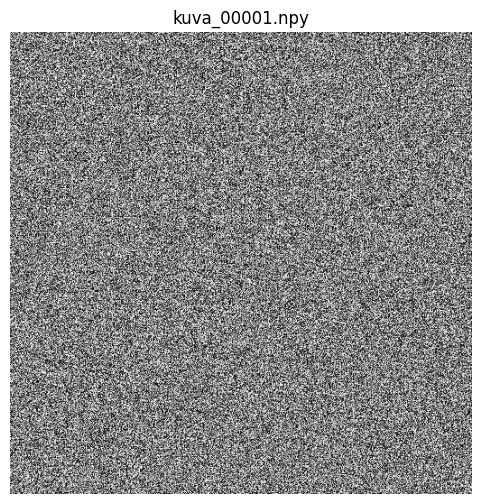

In [37]:
def render_array_to_png(array, image_name, output_dir='rendered_png'):
    if array.ndim != 2:
        raise ValueError(f'Expected a 2D array, got shape {array.shape}')

    output_path = Path(output_dir)
    output_path.mkdir(exist_ok=True)
    png_path = output_path / f'{image_name}.png'

    image = np.clip(array, 0, 255).astype(np.uint8)
    plt.imsave(png_path, image, cmap='gray', vmin=0, vmax=255)
    return png_path

for i in range(len(data)):
    print(f'\nRendering data[{i}] to PNG...')
    rendered_sample = render_array_to_png(data[i], f'data_{i}')
    print('saved png =', rendered_sample)

plt.figure(figsize=(6, 6))
plt.imshow(sample, cmap='gray', vmin=0, vmax=255)
plt.title(files[0].name)
plt.axis('off')
plt.show()